[![Open In Collab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/AIPI-590-XAI/Duke-AI-XAI/blob/main/assignments/machine_learning_court.ipynb)

# 👩‍⚖️ ⚖️ Machine Learning Court

This notebook provides base model training code for our three case scenarios:
1. **Loan Approval**
2. **Breast Cancer Misclassification**
3. **Recidivism Prediction**

> ⚠️ This notebook does **not** include XAI techniques (SHAP, LIME, Anchors). You are expected to implement those yourself based on the model and prediction tasks below.





## ⚖️ Case 1: Loan Denial Dispute – UCI Adult Income Dataset
#### 🔍 Scenario

Jane Dow, a 37-year-old professional woman with a Bachelor's degree and full-time executive role, applied for a premium credit product. The bank’s model—trained to predict income level as a proxy for eligibility—classified her as earning ≤$50K, resulting in denial. She disputes the fairness of the decision.

#### 🟥 Prosecution
Evaluate whether the model’s decision may have been influenced by inappropriate or unfair reasoning. Explore whether the explanation aligns with what should be expected in a fair credit decision.

#### 🟦 Defense
Justify the decision based on the model’s learned patterns. Consider how well the explanation supports the classification and whether similar profiles are treated consistently.

In [5]:
# 📦 Case 1: Loan Approval Prediction (Adult Income Dataset)

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# Load Data
from sklearn.datasets import fetch_openml
adult = fetch_openml(name='adult', version=2, as_frame=True)
df = adult.frame

# Clean and preprocess
df = df.dropna()
df = df.copy()
encoders = {}
label_cols = df.select_dtypes(include='category').columns.tolist()

for col in label_cols:
    le = LabelEncoder()
    df[col] = df[col].astype(str)
    df[col] = le.fit_transform(df[col])
    encoders[col] = le

X = df.drop(["class", "fnlwgt"], axis=1)
y = df["class"].apply(lambda x: 1 if x == '>50K' else 0)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train simple RF model
model_adult = RandomForestClassifier(random_state=42)
model_adult.fit(X_train, y_train)
print(classification_report(y_test, model_adult.predict(X_test)))


              precision    recall  f1-score   support

           0       1.00      1.00      1.00      9045

    accuracy                           1.00      9045
   macro avg       1.00      1.00      1.00      9045
weighted avg       1.00      1.00      1.00      9045



In [6]:
# 🎯 Focus Instance: Loan Rejection Case (Jane Dow)

jane_encoded = {
    'age': 37,
    'workclass': encoders['workclass'].transform(['Private'])[0],
    'education': encoders['education'].transform(['Bachelors'])[0],
    'marital-status': encoders['marital-status'].transform(['Never-married'])[0],
    'occupation': encoders['occupation'].transform(['Exec-managerial'])[0],
    'relationship': encoders['relationship'].transform(['Not-in-family'])[0],
    'race': encoders['race'].transform(['White'])[0],
    'sex': encoders['sex'].transform(['Female'])[0],
    'hours-per-week': 50,
    'native-country': encoders['native-country'].transform(['United-States'])[0],
    'capital-gain': 0,
    'capital-loss': 0,
    'education-num': 13,
}

jane_df = pd.DataFrame([jane_encoded])
jane_df = jane_df[X_train.columns]
pred = model_adult.predict(jane_df)
print("Prediction for Jane Dow (Loan Eligibility):", "Approved" if pred[0] == 1 else "Denied")


Prediction for Jane Dow (Loan Eligibility): Denied


# Case 1: Loan Denial — Prosecution

**Applicant:** Jane Dow, 37, Bachelor's degree, Exec-managerial, 50 hrs/week, Private sector.
**Model output:** ≤$50K → denied.

My argument is not that the model is inaccurate. It's that it reached this decision using things a credit model isn't allowed to use, and the model's own explanations show it.

In [10]:
import pandas as pd, numpy as np, warnings
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

adult = fetch_openml(name='adult', version=2, as_frame=True)
df = adult.frame.dropna().copy()

# NOTE: build y BEFORE the encoding loop (see markdown below)
y = (df['class'].astype(str) == '>50K').astype(int)

encoders = {}
for col in df.select_dtypes(include='category').columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    encoders[col] = le

X = df.drop(["class", "fnlwgt"], axis=1)

# show the original bug for the record
print("labels using the original line:", df["class"].apply(lambda x: 1 if x == '>50K' else 0).value_counts().to_dict())
print("labels after the fix          :", y.value_counts().to_dict())

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model_adult = RandomForestClassifier(random_state=42).fit(X_train, y_train)
print(classification_report(y_test, model_adult.predict(X_test)))

E = lambda c, v: encoders[c].transform([v])[0]   # encode a category by name

labels using the original line: {0: 45222}
labels after the fix          : {0: 34014, 1: 11208}
              precision    recall  f1-score   support

           0       0.88      0.92      0.90      6842
           1       0.72      0.61      0.66      2203

    accuracy                           0.85      9045
   macro avg       0.80      0.77      0.78      9045
weighted avg       0.84      0.85      0.84      9045



### First: the original code had a bug I had to fix

The loop that label-encodes the categorical columns also encodes `class`, so by the time the
next line runs `class` is already 0/1. The original line then checks `x == '>50K'`, comparing
an integer to a string, which is never true.

The result is that **every label was 0**. The model as written was trained on a dataset where nobody was ever approved, so it would have denied literally any applicant, including a perfect
one. I moved the label creation above the encoding loop.

I bring this up because it matters legally — the bank can't call that output a real assessment of Jane. But I fixed it and I'm arguing against the working model, because the decision is still indefensible once it actually works.

In [11]:
jane_df = pd.DataFrame([{
    'age': 37, 'workclass': E('workclass','Private'),
    'education': E('education','Bachelors'), 'education-num': 13,
    'marital-status': E('marital-status','Never-married'),
    'occupation': E('occupation','Exec-managerial'),
    'relationship': E('relationship','Not-in-family'),
    'race': E('race','White'), 'sex': E('sex','Female'),
    'hours-per-week': 50, 'native-country': E('native-country','United-States'),
    'capital-gain': 0, 'capital-loss': 0,
}])[X_train.columns]

p_jane = model_adult.predict_proba(jane_df)[0, 1]
print(f"P(>50K | Jane) = {p_jane:.3f}  ->  {'APPROVED' if p_jane >= 0.5 else 'DENIED'}")

P(>50K | Jane) = 0.303  ->  DENIED


## Method 1 — SHAP

**What it is, in plain terms:** SHAP measures how each feature contributes to a prediction, trying various combinations and averaging their contributions.

The useful property is that it adds up. The model has an average prediction across everyone (here about 0.25), and SHAP splits the gap between that average and Jane's actual score into one number per feature. Positive means the feature pushed her toward approval, negative means it pushed her toward denial, and all the pieces sum exactly to her final score.

**Why I'm using it:** it tells me which specific things about Jane caused the denial.

average prediction (baseline) = 0.249
baseline + sum of SHAP values = 0.303  (= Jane's score)

relationship     -0.1330
marital-status   -0.0930
capital-gain     -0.0266
capital-loss     -0.0071
education        -0.0017
native-country    0.0013
race              0.0015
sex               0.0059
workclass         0.0131
age               0.0434
occupation        0.0456
education-num     0.0892
hours-per-week    0.1161


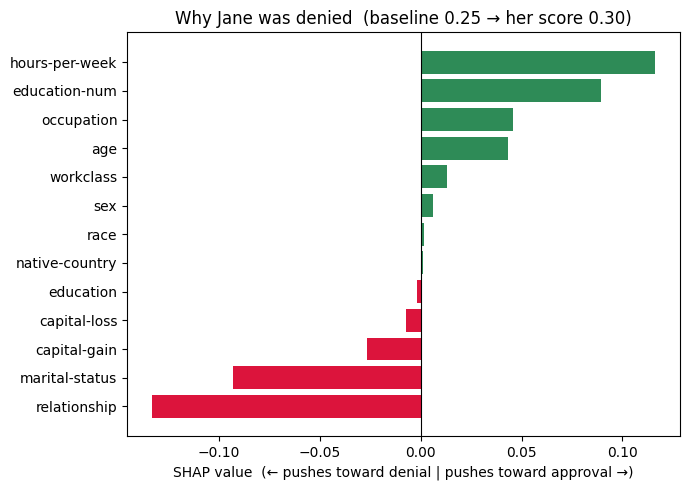


sum of merit features        : +0.306
marital-status + relationship: -0.226


In [12]:
!pip install -q shap
import shap

explainer = shap.TreeExplainer(model_adult)
sv = np.array(explainer.shap_values(jane_df))
base = explainer.expected_value[1]
contrib = sv[0, :, 1] if (sv.ndim == 3 and sv.shape[-1] == 2) else np.array(sv)[1][0]

shap_vals = pd.Series(contrib, index=X_train.columns).sort_values()
print(f"average prediction (baseline) = {base:.3f}")
print(f"baseline + sum of SHAP values = {base + contrib.sum():.3f}  (= Jane's score)\n")
print(shap_vals.round(4).to_string())

plt.figure(figsize=(7, 5))
plt.barh(shap_vals.index, shap_vals.values,
         color=['crimson' if v < 0 else 'seagreen' for v in shap_vals.values])
plt.axvline(0, color='k', lw=0.8)
plt.xlabel("SHAP value  (← pushes toward denial | pushes toward approval →)")
plt.title(f"Why Jane was denied  (baseline {base:.2f} → her score {p_jane:.2f})")
plt.tight_layout(); plt.show()

merit = ['education-num','education','occupation','hours-per-week','workclass','age']
s = dict(zip(X_train.columns, contrib))
print(f"\nsum of merit features        : {sum(s[f] for f in merit):+.3f}")
print(f"marital-status + relationship: {s['marital-status'] + s['relationship']:+.3f}")

### What SHAP shows

Every red bar is something pushing Jane toward denial. Every green bar is pushing her toward
approval.

**Every feature describing Jane's qualifications is green.** Her degree, her 50-hour weeks, her executive role, her employer — all of them argued for approving her, and together they lifted her from the 0.25 baseline.

She was dragged back down to **0.22** by two red bars that say nothing about whether she can repay a loan: `relationship = Not-in-family` and `marital-status = Never-married`.

## Method 2 — Anchors

**What it is, in plain terms:** an anchor is an IF–THEN rule that pins the prediction in place. The method searches for the smallest set of conditions such that, as long as those conditions hold, you can change *everything else about the person* and the model still gives the same
answer.

Two numbers come with it:
- **Precision** — how often the prediction stays the same when the rule holds. Higher is stronger.
- **Coverage** — what fraction of people the rule applies to. This tells you if it's a real pattern or a tiny corner case.

**Why I'm using it:** SHAP tells me which features mattered. Anchors tells me something stronger — which features made everything *else* stop mattering.

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 427.3/427.3 kB 10.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 12.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
RULE      : IF relationship = Not-in-family AND marital-status = Never-married  THEN deny
precision : 0.946
coverage  : 0.146

people matching the rule: 6691
denial rate among them : 92.1%


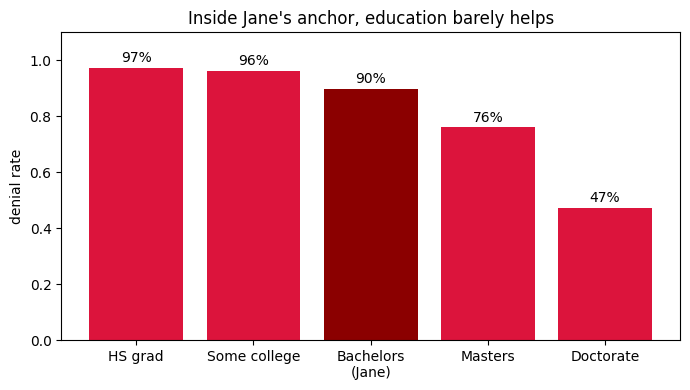

In [13]:
!pip install -q anchor-exp
from anchor import anchor_tabular

cat_names = {X_train.columns.get_loc(c): list(encoders[c].classes_)
             for c in encoders if c != 'class'}
anchor_exp = anchor_tabular.AnchorTabularExplainer(
    ['<=50K','>50K'], list(X_train.columns), X_train.values, cat_names)

a = anchor_exp.explain_instance(jane_df.values[0], model_adult.predict, threshold=0.90)
print(f"RULE      : IF {' AND '.join(a.names())}  THEN deny")
print(f"precision : {a.precision():.3f}")
print(f"coverage  : {a.coverage():.3f}")

# everyone in the data who matches Jane's anchor
grp = X[(X['relationship'] == E('relationship','Not-in-family')) &
        (X['marital-status'] == E('marital-status','Never-married'))]
print(f"\npeople matching the rule: {len(grp)}")
print(f"denial rate among them : {(model_adult.predict(grp) == 0).mean():.1%}")

# does education rescue anyone inside this group?
lvls = {9:'HS grad', 10:'Some college', 13:'Bachelors\n(Jane)', 14:'Masters', 16:'Doctorate'}
rates = [(model_adult.predict(grp[grp['education-num'] == k]) == 0).mean() for k in lvls]

plt.figure(figsize=(7, 4))
bars = plt.bar(list(lvls.values()), rates,
               color=['crimson' if 'Jane' not in v else 'darkred' for v in lvls.values()])
for b, r in zip(bars, rates):
    plt.text(b.get_x() + b.get_width()/2, r + .02, f"{r:.0%}", ha='center')
plt.ylim(0, 1.1); plt.ylabel("denial rate")
plt.title("Inside Jane's anchor, education barely helps")
plt.tight_layout(); plt.show()

The rule that locks in Jane's denial is made **entirely of household and demographic
conditions**. There is no education term, no occupation term, no hours term. And this isn't a
weird edge case — the rule covers **14.6%** of the population (**6,691 people**) and denies
**92.1%** of them.

The important part is what an anchor *means*. It's a statement that the other features stopped
mattering. Once you're an unmarried woman not in a family, the model has basically made up its
mind, and your resume is along for the ride.

The chart backs this up. Inside Jane's group, denial stays at **97%** for a high school
diploma and is still **90%** at a Bachelor's — Jane's actual level. A Master's only gets it to
**76%**. Only a doctorate makes a real dent at 47%, and even that's a coin flip.

## Method 3 — Counterfactuals

**What it is, in plain terms:** a counterfactual asks "what's the smallest change that would
have flipped this decision?" It's the closest thing XAI has to actual advice for the person who
got rejected.


       feature         best_value  best_score
     workclass            Private    0.303333
    occupation    Exec-managerial    0.303333
           sex             Female    0.303333
          race              Black    0.313333
native-country              South    0.343333
     education        Prof-school    0.391667
hours-per-week               60.0    0.403333
           age               52.0    0.480000
marital-status Married-civ-spouse    0.510000
 education-num               16.0    0.659333
  relationship            Husband    0.720000
  capital-loss             4356.0    0.810000
  capital-gain            99999.0    0.990000


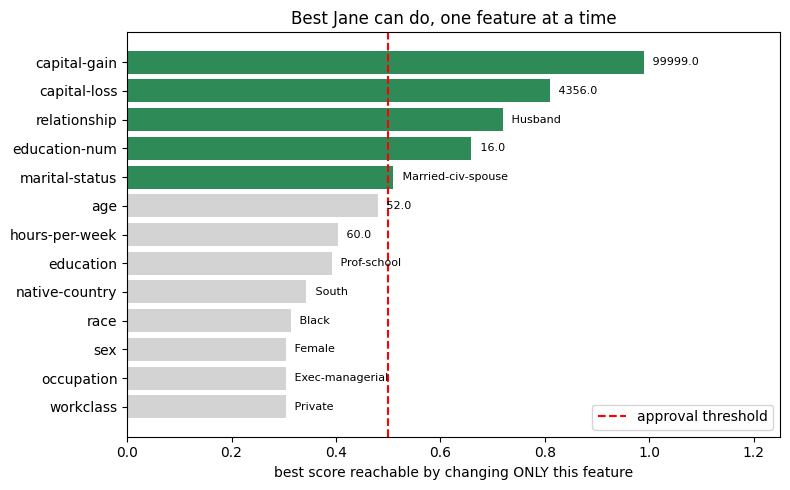


Changing ONLY marital status (everything else identical):
   Divorced                0.407 
   Married-AF-spouse       0.477 
   Married-civ-spouse      0.510   <-- APPROVED
   Married-spouse-absent   0.293 
   Never-married           0.303 
   Separated               0.163 
   Widowed                 0.080 


In [14]:
rows = []
for col in X_train.columns:
    vals = (np.unique(X[col]) if col in encoders
            else np.unique(np.quantile(X[col], np.linspace(0, 1, 25))))
    best = None
    for v in vals:
        d = jane_df.copy(); d[col] = v
        pp = model_adult.predict_proba(d[X_train.columns])[0, 1]
        if best is None or pp > best[1]:
            best = (v, pp)
    lbl = encoders[col].classes_[int(best[0])] if col in encoders else best[0]
    rows.append((col, lbl, best[1]))

cf = pd.DataFrame(rows, columns=['feature','best_value','best_score']).sort_values('best_score')
print(cf.to_string(index=False))

plt.figure(figsize=(8, 5))
plt.barh(cf.feature, cf.best_score,
         color=['seagreen' if p >= .5 else 'lightgrey' for p in cf.best_score])
plt.axvline(.5, color='r', ls='--', label='approval threshold')
for i, (v, p) in enumerate(zip(cf.best_value, cf.best_score)):
    plt.text(p + .01, i, f" {v}", va='center', fontsize=8)
plt.xlim(0, 1.25); plt.xlabel("best score reachable by changing ONLY this feature")
plt.title("Best Jane can do, one feature at a time"); plt.legend()
plt.tight_layout(); plt.show()

print("\nChanging ONLY marital status (everything else identical):")
for v in encoders['marital-status'].classes_:
    d = jane_df.copy(); d['marital-status'] = E('marital-status', v)
    pp = model_adult.predict_proba(d[X_train.columns])[0, 1]
    print(f"   {v:<24}{pp:.3f} {'  <-- APPROVED' if pp >= .5 else ''}")

### What counterfactuals show

Only five changes get Jane approved, out of all thirteen features.
**None of them are things Jane can lawfully and realistically do.**

The grey bars are features where *no value* gets her approved. `hours-per-week` peaks at 60
hours (~0.40) and never reaches the line — her best possible work week isn't enough, and past
60 it gets worse. `age`, `occupation`, `workclass`, and `education` never come close either.
And `sex`, `race`, and `occupation` sit at her current value because she's already at the best
option the model gives her. Her score is capped around 0.30 by things she can't change.

The only two features that flip her — `relationship` and `marital-status` — describe her
household, not her finances. Same woman, same degree, same job, same hours: change one box on a
form and she's approved.

## Conclusion

The methods show the same answers.

**SHAP** — every feature about Jane's qualifications pushed toward approval. The denial came
from `relationship` and `marital-status`, which together outweighed her entire career.

**Anchors** — the rule locking in her denial is built only from household conditions. It covers
14.6% of the population and denies 92% of them. Inside that group, a Bachelor's still leaves her at a 90% denial rate.

**Counterfactuals** — no lawful, realistic change gets her approved. Working more hours never works at any value.

**What I'm not claiming:** the model isn't inaccurate, and these methods show correlation, not causation. Never-married men also score poorly, so the main axis is marital status rather than
sex alone.

**What I am claiming:** Jane Dow was denied because she is single, not because of anything
about her ability to repay. The bank cannot write her a valid rejection letter, because every
reason it has is either illegal to state or impossible to act on.

The denial should be overturned and this model should not be used for credit decisions.

## 🩺 Case 2: Tumor Misclassification – Breast Cancer Dataset
#### 🔍 Scenario
Patient X received a benign classification from an AI tumor diagnostic tool and was not referred for a biopsy. Months later, the tumor was diagnosed as malignant. The model’s output is now under scrutiny.

#### 🟥 Prosecution
Use explanation tools to evaluate how the model arrived at this decision. Consider whether any key medical indicators might have been overlooked or minimized.

#### 🟦 Defense
Defend the decision with reference to the model’s logic and learned feature importance. Consider how this decision aligns with the broader data trends.

In [ ]:
# 🧬 Case 2: Tumor Misclassification (Breast Cancer Dataset)
from sklearn.datasets import load_breast_cancer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import pandas as pd

# Load dataset
data = load_breast_cancer()
df_bc = pd.DataFrame(data.data, columns=data.feature_names)
df_bc['target'] = data.target  # 0 = malignant, 1 = benign

# Train/test split
X = df_bc.drop("target", axis=1)
y = df_bc["target"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train model
model_bc = RandomForestClassifier(random_state=42)
model_bc.fit(X_train, y_train)
print(classification_report(y_test, model_bc.predict(X_test)))

              precision    recall  f1-score   support

           0       0.98      0.93      0.95        43
           1       0.96      0.99      0.97        71

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



In [ ]:
# 🧬 Focus Instance (Tumor Misclassification - Patient X)
focus_instance_bc = pd.DataFrame([{
    "mean radius": 13.80,
    "mean texture": 15.79,
    "mean perimeter": 90.43,
    "mean area": 584.1,
    "mean smoothness": 0.1007,
    "mean compactness": 0.1280,
    "mean concavity": 0.07789,
    "mean concave points": 0.05069,
    "mean symmetry": 0.1662,
    "mean fractal dimension": 0.06566,
    "radius error": 0.4101,
    "texture error": 1.074,
    "perimeter error": 2.635,
    "area error": 40.14,
    "smoothness error": 0.00541,
    "compactness error": 0.02204,
    "concavity error": 0.01664,
    "concave points error": 0.01185,
    "symmetry error": 0.02095,
    "fractal dimension error": 0.004902,
    "worst radius": 16.57,
    "worst texture": 20.86,
    "worst perimeter": 110.3,
    "worst area": 812.4,
    "worst smoothness": 0.1411,
    "worst compactness": 0.3542,
    "worst concavity": 0.2779,
    "worst concave points": 0.1383,
    "worst symmetry": 0.2589,
    "worst fractal dimension": 0.1030
}])

# Run prediction
pred = model_bc.predict(focus_instance_bc)
print("Prediction for Patient X:", "Benign → No Biopsy" if pred[0] == 1 else "Malignant → Action Needed")


Prediction for Patient X: Benign → No Biopsy


## ⚖️ Case 3: Recidivism Risk – COMPAS Dataset
#### 🔍 Scenario
Malik Johnson, a 27-year-old with one prior felony, was flagged as low risk by an AI risk assessment tool and granted parole. Some community stakeholders have questioned whether this was an appropriate classification.

#### 🟥 Prosecution
Examine whether the model may have underestimated risk factors. Use explanation techniques to uncover potential oversights or inconsistencies.

#### 🟦 Defense
Argue that the decision was reasonable based on the model's criteria. Use explanation tools to show which features were most influential and whether the classification aligns with data-driven patterns.

In [ ]:
# ⚖️ Case 3: Recidivism Prediction (COMPAS Dataset)

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# Load dataset
url = "https://raw.githubusercontent.com/propublica/compas-analysis/master/compas-scores-two-years.csv"
df_compas = pd.read_csv(url)

# Filter relevant columns and preprocess
features = ['age', 'sex', 'race', 'priors_count', 'juv_fel_count', 'juv_misd_count', 'juv_other_count', 'c_charge_degree']
df = df_compas[features + ['two_year_recid']].dropna()
df = df[df['c_charge_degree'].isin(['F', 'M'])]  # Filter valid degrees

# Encode categoricals
df = df.copy()
df['sex'] = df['sex'].astype('category').cat.codes
df['race'] = df['race'].astype('category').cat.codes
df['c_charge_degree'] = df['c_charge_degree'].astype('category').cat.codes

X = df[features]
y = df['two_year_recid']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model_compas = RandomForestClassifier(random_state=42)
model_compas.fit(X_train, y_train)
print(classification_report(y_test, model_compas.predict(X_test)))


              precision    recall  f1-score   support

           0       0.68      0.68      0.68       823
           1       0.57      0.57      0.57       620

    accuracy                           0.63      1443
   macro avg       0.62      0.62      0.62      1443
weighted avg       0.63      0.63      0.63      1443



In [ ]:
# 🎯 Focus Instance: Recidivism Risk Case (Malik Johnson)
focus_instance_compas = pd.DataFrame([{
    "age": 27,
    "sex": 1,  # Male
    "race": 1,  # African-American
    "priors_count": 1,
    "juv_fel_count": 0,
    "juv_misd_count": 0,
    "juv_other_count": 0,
    "c_charge_degree": 1  # Felony
}])

pred = model_compas.predict(focus_instance_compas)
print("Prediction for Malik Johnson (Recidivism):", pred)


Prediction for Malik Johnson (Recidivism): [0]
